# Sampled phylogenies: genetic and dated

Simulate a small outbreak, infer a reference-rooted genetic tree with IQ-TREE, and date the sampled-case tree with LSD2.

**Setup:** from the project root, install the notebook dependencies:
```bash
python -m pip install -e '.[phylogeny]' matplotlib jupyterlab
```
Install [IQ-TREE](https://iqtree.github.io/#download) **2.0.6 or later** separately. Put `iqtree3`, `iqtree2`, or `iqtree` on `PATH`, or set `IQTREE_EXECUTABLE` below to its path. Run the cells in order.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from Bio import Phylo, SeqIO
from matplotlib.ticker import FuncFormatter

from epilink import (
    InfectiousnessToTransmission,
    NaturalHistoryParameters,
    build_phylogenetic_tree,
    build_phylogenetic_tree_from_fasta,
    simulate_epidemic_dates,
    simulate_genomic_sequences,
)

IQTREE_EXECUTABLE = os.environ.get("EPILINK_IQTREE")  # None means discover on PATH
OUTPUT_DIR = Path.cwd() / "build" / "phylogeny_demo"

## 1. Simulate genomes and sampling dates

Use 15 cases, sample 80%, and simulate 2,000 aligned sites. The toy substitution rate is increased to make variation visible in this short example. The profile and sequence simulator use the same genome length, and `relaxation=0` gives a fixed simulation clock.

`return_raw=False` demonstrates that phylogenetic inference can decode the packed sequences directly.

In [2]:
parameters = NaturalHistoryParameters(
    genome_length=2000,
    substitution_rate=0.1,  # substitutions/site/year; toy rate
    relaxation=0.0,
)
profile = InfectiousnessToTransmission(parameters=parameters, rng_seed=2026)
transmission_tree = nx.balanced_tree(r=2, h=3, create_using=nx.DiGraph)
transmission_tree = nx.relabel_nodes(
    transmission_tree, {node: f"case-{node:02d}" for node in transmission_tree}
)
epidemic_tree = simulate_epidemic_dates(profile, transmission_tree, fraction_sampled=0.8)
simulated = simulate_genomic_sequences(
    profile, epidemic_tree, genome_length=parameters.genome_length, return_raw=False
)

sampled_cases = pd.DataFrame(
    [
        {"case_id": node, "sample_date": data["sample_date"]}
        for node, data in epidemic_tree.nodes(data=True)
        if data["sampled"]
    ]
).sort_values("sample_date", ignore_index=True)
print(f"{len(sampled_cases)} sampled cases out of {len(epidemic_tree)}")
print("Reference (first 60 bases):", simulated.reference_sequence_string[:60])
sampled_cases

12 sampled cases out of 15
Reference (first 60 bases): AACTTCGTGTAGCCTCGGATTTGCCAATGCCCACTATCAACACCGCTGGCACTTTTATCC


,case_id,sample_date
0,case-00,33.195109
1,case-02,35.191003
2,case-03,36.470027
3,case-10,43.237353
4,case-08,43.244403
5,case-09,45.179715
6,case-05,47.709531
7,case-14,49.501008
8,case-04,49.657340
9,case-07,51.966043


## 2. Infer both phylogenies

Infer from the **stochastic** sequences of sampled cases. The epidemic graph supplies sample flags and dates; its transmission edges do not determine the inferred topology.

For this small example, fix the dating clock to the simulation rate, converted from substitutions/site/year to **substitutions/site/day**. Set `clock_rate=None` to estimate it from sampling dates, or `sequence_model="deterministic"` to use the other sequence set.

In [3]:
phylogeny = build_phylogenetic_tree(
    simulated,
    epidemic_tree,
    sequence_model="stochastic",
    dated=True,
    model="JC",
    clock_rate=parameters.substitution_rate / 365.0,
    output_dir=OUTPUT_DIR,
    iqtree_executable=IQTREE_EXECUTABLE,
    threads=1,
    seed=2026,
    timeout=120,
)

print(f"Dating clock: {phylogeny.clock_rate:.6g} substitutions/site/day")
phylogeny.node_dates.sort_values("date", ignore_index=True)

Dating clock: 0.000273973 substitutions/site/day


,node,case_id,is_tip,date,sample_date
0,internal_0,None,False,28.0629,NaN
1,internal_1,None,False,30.0870,NaN
2,internal_2,None,False,32.4388,NaN
3,internal_3,None,False,32.4388,NaN
4,internal_6,None,False,32.5511,NaN
5,case-00,case-00,True,33.1951,33.195109
6,case-02,case-02,True,35.1910,35.191003
7,case-03,case-03,True,36.4700,36.470027
8,internal_7,None,False,36.4700,NaN
9,internal_8,None,False,36.4700,NaN


## 3. Compare genetic and dated trees

The genetic tree includes the reference outgroup and has branch lengths in **substitutions/site**. The dated tree excludes the undated reference and has branch lengths in **days**. Its x-axis below is offset by the inferred root date to show the original simulation time scale.

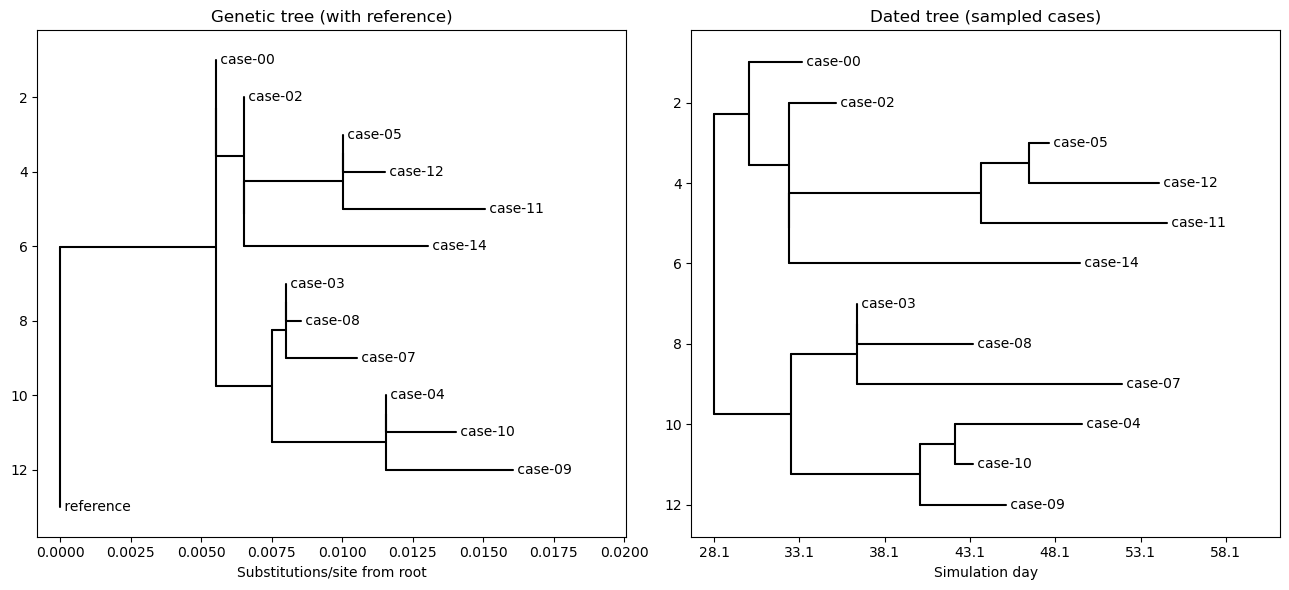

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for tree, axis in zip([phylogeny.raw_tree, phylogeny.dated_tree], axes, strict=True):
    Phylo.draw(
        tree,
        axes=axis,
        do_show=False,
        show_confidence=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else None,
    )
    axis.set_ylabel("")

axes[0].set_title("Genetic tree (with reference)")
axes[0].set_xlabel("Substitutions/site from root")
root_date = phylogeny.node_dates.set_index("node").loc[phylogeny.dated_tree.root.name, "date"]
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda elapsed, _: f"{root_date + elapsed:.1f}"))
axes[1].set_title("Dated tree (sampled cases)")
axes[1].set_xlabel("Simulation day")
fig.tight_layout()
plt.show()

## 4. Find exported files

Each run writes files under `build/phylogeny_demo/run-*/` relative to the working directory: sampled FASTA, genetic Newick, dated Newick/NEXUS, node dates, and inference logs.

FASTA uses safe backend taxon labels mapped to case IDs in `taxon_labels.tsv`; returned trees and exported `raw_tree` / `dated_tree` files restore the original case labels.

In [5]:
pd.DataFrame(
    [{"artifact": name, "path": str(path)} for name, path in phylogeny.output_paths.items()]
)

,artifact,path
0,alignment,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
1,taxon_labels,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
2,log,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
3,iqtree_report,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
4,iqtree_tree,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
5,raw_tree,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
6,sampling_dates,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
7,lsd_report,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
8,lsd_tree,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
9,dated_tree,/Users/ydnkka/Desktop/PhD Project/Projects/epi...


## 5. Start from an aligned FASTA and date CSV

For file-based input, use `build_phylogenetic_tree_from_fasta`. Here we export the sampled alignment with original case IDs and map the toy sampling times onto calendar dates (day precision). Replace these two files with your own aligned FASTA and CSV containing `case_id,sample_date`.

The reference is selected from the alignment by ID. Alternatively, supply `reference_fasta="aligned_reference.fasta"` with a samples-only alignment. Numeric day values or an ID-to-date mapping work too. Calendar input returns a `date_origin` and calendar columns alongside day-based node dates.

In [ ]:
labels = pd.read_csv(
    phylogeny.output_paths["taxon_labels"], sep="\t", dtype=str, keep_default_na=False
)
label_map = dict(zip(labels["taxon"], labels["case_id"], strict=True))
records = list(SeqIO.parse(phylogeny.output_paths["alignment"], "fasta"))
for record in records:
    record.id = label_map[record.id]
    record.description = ""
alignment_path = OUTPUT_DIR / "aligned_samples_with_reference.fasta"
SeqIO.write(records, alignment_path, "fasta")

calendar_samples = sampled_cases.copy()
elapsed_days = calendar_samples["sample_date"] - calendar_samples["sample_date"].min()
calendar_samples["sample_date"] = (
    pd.Timestamp("2026-10-01") + pd.to_timedelta(elapsed_days, unit="D")
).dt.strftime("%Y-%m-%d")
dates_path = OUTPUT_DIR / "calendar_dates.csv"
calendar_samples.to_csv(dates_path, index=False)

from_fasta = build_phylogenetic_tree_from_fasta(
    alignment_path,
    reference_id=phylogeny.reference_name,
    dates=dates_path,
    model="JC",
    clock_rate=parameters.substitution_rate / 365.0,
    output_dir=OUTPUT_DIR / "from_fasta",
    iqtree_executable=IQTREE_EXECUTABLE,
    timeout=120,
)
print("Calendar origin:", from_fasta.date_origin)
from_fasta.node_dates[["node", "date", "calendar_date", "sample_calendar_date"]]